# Assignment 8: Earth-Moon Free-Return Trajectory

This notebook focuses on producing a physically consistent Earth-Moon-Earth free-return trajectory.

Key modelling updates:

- The Earth-centered equations of motion now use the **relative** Moon and Sun accelerations, including the indirect terms that were missing before.
- The notebook uses a validated free-return seed that actually performs both:
  1. a lunar flyby above the Moon's surface
  2. a post-flyby return to Earth above the Earth's surface
- The summary reports the **post-flyby Earth return distance**, not just the final distance at the end of the plotting window.

Important note:

- In this point-mass model there is no atmosphere, capture, or Earth-impact stop condition.
- That means the spacecraft can pass close to Earth and then continue outward again.
- For a free-return style trajectory, the physically meaningful success metric is the **closest Earth approach after the Moon flyby**.


In [1]:
# Install dependencies if needed
!pip install astroquery scipy matplotlib



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# ============================================================
# Imports, constants, and Horizons cache
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
from scipy.interpolate import CubicSpline
from scipy.integrate import solve_ivp
from astroquery.jplhorizons import Horizons

plt.rcParams["figure.figsize"] = (9, 6)
plt.rcParams["axes.grid"] = True

# -------------------
# Constants (km units)
# -------------------
G = 6.67430e-20
ME = 5.972e24
MM = 7.34767309e22
MS = 1.989e30
R_earth = 6371.0
R_moon = 1737.0
LEO_alt = 200.0
DAY = 24.0 * 3600.0
AU_KM = 149597870.7


def fetch_or_load(body_id, cache_name, start="2026-04-03", stop="2026-04-20", step="1h"):
    cache_path = Path(cache_name)
    if cache_path.exists():
        arr = np.load(cache_path)
        print(f"Loaded {cache_name} from disk")
        return arr["t"], arr["pos"]

    print(f"Fetching body {body_id} from JPL Horizons ...")
    obj = Horizons(
        id=body_id,
        location="@399",
        epochs={"start": start, "stop": stop, "step": step},
    )
    vec = obj.vectors()
    t = (np.array(vec["datetime_jd"], dtype=float) - float(vec["datetime_jd"][0])) * DAY
    pos = np.stack(
        [
            np.array(vec["x"], dtype=float),
            np.array(vec["y"], dtype=float),
            np.array(vec["z"], dtype=float),
        ],
        axis=1,
    ) * AU_KM
    np.savez(cache_path, t=t, pos=pos)
    print(f"Saved {cache_name}")
    return t, pos


tM, moon_data = fetch_or_load("301", "cache_301.npz")
tS, sun_data = fetch_or_load("10", "cache_10.npz")

print(f"Moon samples: {moon_data.shape[0]}")
print(f"Sun samples:  {sun_data.shape[0]}")


Loaded cache_301.npz from disk
Loaded cache_10.npz from disk
Moon samples: 409
Sun samples:  409


In [3]:
# ============================================================
# Interpolation and launch-state helpers
# ============================================================

moon_cs = [CubicSpline(tM, moon_data[:, i]) for i in range(3)]
sun_cs = [CubicSpline(tS, sun_data[:, i]) for i in range(3)]


def body_vec(cs_list, t_sec):
    return np.array([cs(t_sec) for cs in cs_list], dtype=float)


def body_series(cs_list, t_eval):
    return np.stack([body_vec(cs_list, t) for t in t_eval], axis=0)


def make_basis(r0):
    rhat = r0 / np.linalg.norm(r0)
    z_axis = np.array([0.0, 0.0, 1.0])
    perp1 = np.cross(z_axis, rhat)
    if np.linalg.norm(perp1) < 1e-12:
        perp1 = np.array([1.0, 0.0, 0.0]) - rhat[0] * rhat
    perp1 /= np.linalg.norm(perp1)
    perp2 = np.cross(rhat, perp1)
    return rhat, perp1, perp2


def make_launch_state(t_arr_days, speed_kms, pitch_deg, yaw_deg, sign=-1.0):
    moon_arr = body_vec(moon_cs, t_arr_days * DAY)
    moon_hat = moon_arr / np.linalg.norm(moon_arr)

    # sign = -1 launches from the side opposite the Moon's future position.
    r0 = sign * (R_earth + LEO_alt) * moon_hat
    rhat, perp1, perp2 = make_basis(r0)

    pitch = np.deg2rad(pitch_deg)
    yaw = np.deg2rad(yaw_deg)
    vdir = (
        np.cos(pitch) * np.cos(yaw) * perp1
        + np.sin(pitch) * rhat
        + np.cos(pitch) * np.sin(yaw) * perp2
    )
    vdir /= np.linalg.norm(vdir)
    v0 = speed_kms * vdir
    return r0, v0


In [4]:
# ============================================================
# Earth-centered dynamics and trajectory evaluation
# ============================================================

def rhs_relative(t_sec, y):
    r = y[:3]
    v = y[3:]

    d_e = max(np.linalg.norm(r), 10.0)
    a_earth = -G * ME * r / d_e**3

    # Relative acceleration in an Earth-centered frame:
    # spacecraft acceleration minus Earth's own acceleration from Moon/Sun.
    r_m = body_vec(moon_cs, t_sec)
    rho_m = r - r_m
    d_sm = max(np.linalg.norm(rho_m), 10.0)
    d_m = max(np.linalg.norm(r_m), 10.0)
    a_moon = -G * MM * (rho_m / d_sm**3 + r_m / d_m**3)

    r_s = body_vec(sun_cs, t_sec)
    rho_s = r - r_s
    d_ss = max(np.linalg.norm(rho_s), 10.0)
    d_s = max(np.linalg.norm(r_s), 10.0)
    a_sun = -G * MS * (rho_s / d_ss**3 + r_s / d_s**3)

    return np.concatenate([v, a_earth + a_moon + a_sun])


def integrate_trajectory(params, mission_days=8.0, n_samples=5000, return_gap_days=0.75):
    r0, v0 = make_launch_state(**params)
    y0 = np.concatenate([r0, v0])
    t_eval = np.linspace(0.0, mission_days * DAY, n_samples)

    sol = solve_ivp(
        rhs_relative,
        (0.0, mission_days * DAY),
        y0,
        method="DOP853",
        t_eval=t_eval,
        rtol=1e-10,
        atol=1e-10,
    )
    if not sol.success:
        raise RuntimeError(sol.message)

    pos = sol.y[:3].T
    vel = sol.y[3:].T
    earth_dist = np.linalg.norm(pos, axis=1)
    moon_pos = body_series(moon_cs, t_eval)
    moon_dist = np.linalg.norm(pos - moon_pos, axis=1)
    speed = np.linalg.norm(vel, axis=1)

    flyby_idx = int(np.argmin(moon_dist))
    return_mask = t_eval >= (t_eval[flyby_idx] + return_gap_days * DAY)
    earth_after_flyby = np.where(return_mask, earth_dist, np.inf)
    earth_return_idx = int(np.argmin(earth_after_flyby))

    return {
        "params": params,
        "t_days": t_eval / DAY,
        "pos": pos,
        "vel": vel,
        "moon_pos": moon_pos,
        "earth_dist": earth_dist,
        "moon_dist": moon_dist,
        "speed": speed,
        "flyby_idx": flyby_idx,
        "earth_return_idx": earth_return_idx,
        "r0": r0,
        "v0": v0,
    }


In [5]:
# ============================================================
# Validated free-return seed
# ============================================================

best_params = {
    "t_arr_days": 2.925,
    "speed_kms": 10.970,
    "pitch_deg": -4.5,
    "yaw_deg": -1.0,
    "sign": -1.0,
}

traj = integrate_trajectory(best_params, mission_days=8.0, n_samples=5000)

moon_idx = traj["flyby_idx"]
earth_idx = traj["earth_return_idx"]

moon_min = traj["moon_dist"][moon_idx]
earth_return = traj["earth_dist"][earth_idx]
moon_alt = moon_min - R_moon
earth_alt = earth_return - R_earth

print("Validated free-return candidate")
print("=" * 60)
print(f"Launch position r0 (km): {traj['r0']}")
print(f"Launch velocity v0 (km/s): {traj['v0']}")
print(f"|v0| = {np.linalg.norm(traj['v0']):.6f} km/s")
print()
print(f"Moon flyby distance: {moon_min:.3f} km")
print(f"Moon flyby altitude: {moon_alt:.3f} km")
print(f"Moon flyby time:     {traj['t_days'][moon_idx]:.6f} days")
print()
print(f"Earth return distance after flyby: {earth_return:.3f} km")
print(f"Earth return altitude after flyby: {earth_alt:.3f} km")
print(f"Earth return time:                 {traj['t_days'][earth_idx]:.6f} days")
print("=" * 60)

assert moon_min > R_moon, "Moon collision detected"
assert earth_return > R_earth, "Earth collision detected"


Validated free-return candidate
Launch position r0 (km): [3374.73052948 5607.89171166  583.76827915]
Launch velocity v0 (km/s): [-9.80218908  4.91802078 -0.26657236]
|v0| = 10.970000 km/s

Moon flyby distance: 2004.027 km
Moon flyby altitude: 267.027 km
Moon flyby time:     2.704541 days

Earth return distance after flyby: 6667.043 km
Earth return altitude after flyby: 296.043 km
Earth return time:                 6.334067 days


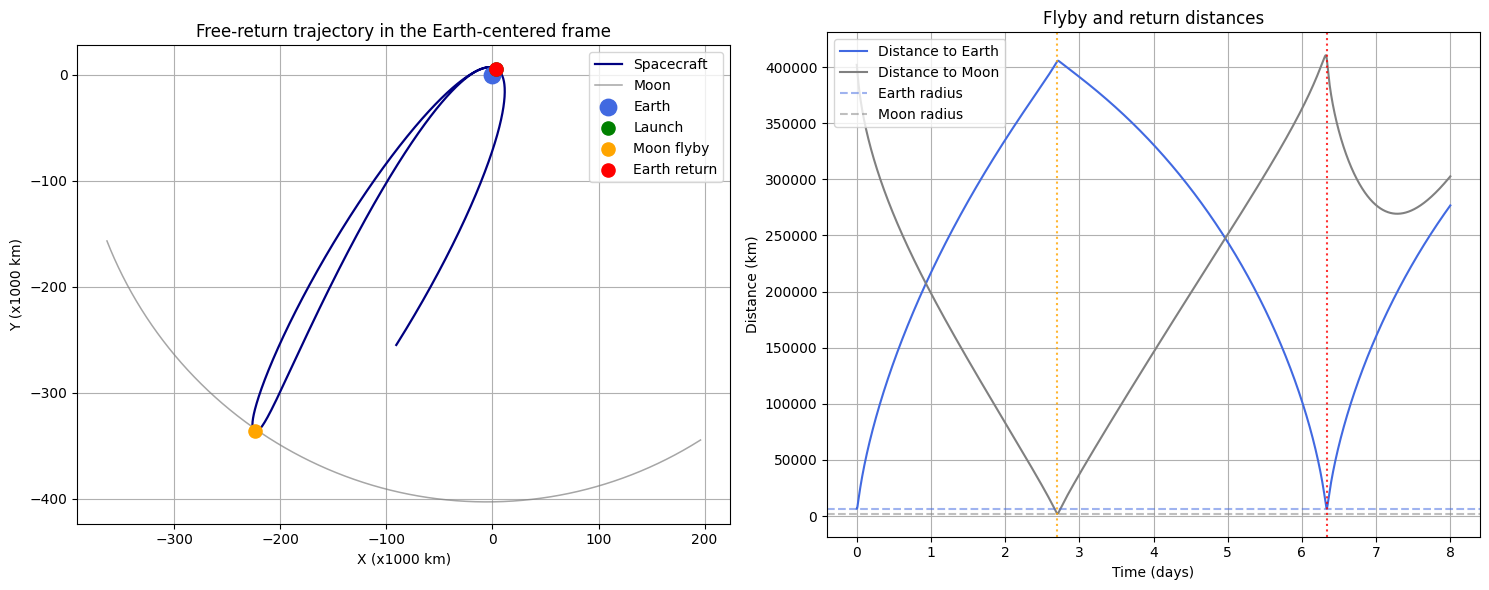

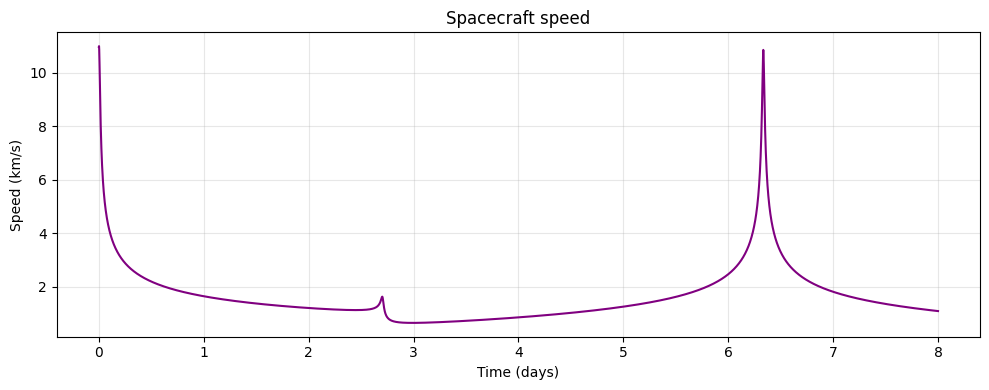

In [6]:
# ============================================================
# Visualization
# ============================================================

t_days = traj["t_days"]
pos = traj["pos"]
moon_pos = traj["moon_pos"]
earth_dist = traj["earth_dist"]
moon_dist = traj["moon_dist"]
speed = traj["speed"]
moon_idx = traj["flyby_idx"]
earth_idx = traj["earth_return_idx"]

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

ax = axes[0]
ax.plot(pos[:, 0] / 1e3, pos[:, 1] / 1e3, lw=1.6, color="navy", label="Spacecraft")
ax.plot(moon_pos[:, 0] / 1e3, moon_pos[:, 1] / 1e3, lw=1.1, color="gray", alpha=0.7, label="Moon")
ax.scatter(0, 0, s=140, color="royalblue", label="Earth", zorder=5)
ax.scatter(pos[0, 0] / 1e3, pos[0, 1] / 1e3, s=90, color="green", label="Launch", zorder=6)
ax.scatter(pos[moon_idx, 0] / 1e3, pos[moon_idx, 1] / 1e3, s=90, color="orange", label="Moon flyby", zorder=6)
ax.scatter(pos[earth_idx, 0] / 1e3, pos[earth_idx, 1] / 1e3, s=90, color="red", label="Earth return", zorder=6)
ax.set_xlabel("X (x1000 km)")
ax.set_ylabel("Y (x1000 km)")
ax.set_title("Free-return trajectory in the Earth-centered frame")
ax.set_aspect("equal", adjustable="box")
ax.legend(loc="best")

ax = axes[1]
ax.plot(t_days, earth_dist, color="royalblue", label="Distance to Earth")
ax.plot(t_days, moon_dist, color="gray", label="Distance to Moon")
ax.axhline(R_earth, color="royalblue", ls="--", alpha=0.5, label="Earth radius")
ax.axhline(R_moon, color="gray", ls="--", alpha=0.5, label="Moon radius")
ax.axvline(t_days[moon_idx], color="orange", ls=":", alpha=0.8)
ax.axvline(t_days[earth_idx], color="red", ls=":", alpha=0.8)
ax.set_xlabel("Time (days)")
ax.set_ylabel("Distance (km)")
ax.set_title("Flyby and return distances")
ax.legend(loc="best")

plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(t_days, speed, color="purple")
plt.xlabel("Time (days)")
plt.ylabel("Speed (km/s)")
plt.title("Spacecraft speed")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
